# Employee Promotion Prediction Engine

**Dataset:** [HR Analytics: Employee Promotion (Kaggle)](https://www.kaggle.com/datasets/arashnic/hr-ana)

## 1. Problem Statement & Dataset Overview

**Business Problem:**
Promotion decisions inside most organizations are inconsistent - shaped by manager bias, visibility, or who
advocates loudest for themselves, rather than purely by performance and readiness. This means employees who
are genuinely promotion-ready sometimes get overlooked, while HR has no systematic, data-backed way to flag
who is ready *before* the annual review cycle happens.

**Project Goal:**
Build a classification model that predicts whether an employee will be promoted, using performance ratings,
training scores, tenure, and past achievements — trained on real historical promotion outcomes as ground
truth, so the results are auditable and defensible rather than a guessed or circular label.

**Why This Matters:**
- Gives HR an objective, data-driven shortlist of promotion-ready employees ahead of review cycles
- Surfaces strong performers who might otherwise be passed over
- Feature importance makes the model's reasoning auditable, which matters given the fairness/compliance
  weight that promotion decisions carry

## 1. Data Acquisition
Before any modeling can happen, the raw data needs to be acquired, audited, and understood. This section 
handles that first stage: pulling in the dataset, cleaning it, and running the initial EDA that will surface
which features are worth engineering further and which patterns the model needs to account for. 

In [134]:
#Loading the Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [135]:
# Loading the dataset
df = pd.read_csv("../data/train.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

# Structural overview: column names, non-null counts, and data types
df.info()

Dataset shape: 54808 rows, 13 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


**Note on dataset version:** this particular download does **not** include a `KPIs_met >80%` column (some public mirrors of this dataset do). The team's feature-engineering plan for a KPI-met flag will need to be adjusted.


In [136]:
# Quick look at key numeric columns before any cleaning
df[['previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score']].describe()

,previous_year_rating,length_of_service,awards_won?,avg_training_score
count,50684.000000,54808.000000,54808.000000,54808.000000
mean,3.329256,5.865512,0.023172,63.386750
std,1.259993,4.265094,0.150450,13.371559
min,1.000000,1.000000,0.000000,39.000000
25%,3.000000,3.000000,0.000000,51.000000
50%,3.000000,5.000000,0.000000,60.000000
75%,4.000000,7.000000,0.000000,76.000000
max,5.000000,37.000000,1.000000,99.000000


## 2. Data Cleaning & Quality Audit

Before any EDA is trustworthy, we run a full data-hygiene pass:
- Check and document missing values (before/after)
- Investigate *why* values are missing rather than blindly imputing
- Remove duplicate rows
- Confirm the dataset is clean and save it for Feature Engineering


In [137]:
# Missing Values Audit (BEFORE cleaning)
missing_before = df.isnull().sum()
missing_before_pct = (missing_before / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %': missing_before_pct.round(2)
}).sort_values(by='Missing Count', ascending=False)

print("Missing Values BEFORE Cleaning:")
missing_report[missing_report['Missing Count'] > 0]

Missing Values BEFORE Cleaning:


,Missing Count,Missing %
previous_year_rating,4124,7.52
education,2409,4.40


#### Handling `previous_year_rating`

This is the field the team flagged as needing careful handling. Rather than filling it with the median or mean (which would fabricate a performance signal that doesn't exist), we first test a hypothesis: are these missing ratings concentrated among **new hires** who haven't completed a review cycle yet?


In [138]:
# Test hypothesis: missing previous_year_rating correlates with length_of_service
missing_rating_mask = df['previous_year_rating'].isnull()
print("length_of_service stats for rows missing previous_year_rating:")
df.loc[missing_rating_mask, 'length_of_service'].describe()

length_of_service stats for rows missing previous_year_rating:


count    4124.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: length_of_service, dtype: float64

**Confirmed:** every single row missing `previous_year_rating` has `length_of_service == 1`. This isn't
random missingness - it's a structural "not yet rated" case for employees who joined too recently to have
a prior review. Filling this with the median (typically ~3) would incorrectly imply average performance for
employees the company simply hasn't rated yet.

**Decision:** impute with `0`, a value outside the real 1–5 rating scale, so the model can learn "new hire,
unrated" as its own distinct signal rather than conflating it with a mediocre performance rating.


In [139]:
# Impute previous_year_rating with 0 (distinct from real 1-5 ratings)
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)
print("Remaining missing values in previous_year_rating:", df['previous_year_rating'].isnull().sum())

Remaining missing values in previous_year_rating: 0


#### Handling `education`

`education` is a categorical field with no obvious structural pattern behind its missing values (unlike `previous_year_rating`), so we impute with the mode - the most common education level in the dataset - which is a reasonable default for a categorical variable with no missing-value pattern to exploit.


In [140]:
# Impute education with the mode (most frequent category)
missing_edu_count = df['education'].isnull().sum()
df['education'] = df['education'].fillna(df['education'].mode()[0])
print(f"Imputed {missing_edu_count} missing 'education' values with the mode: '{df['education'].mode()[0]}'")

Imputed 2409 missing 'education' values with the mode: 'Bachelor's'


#### Duplicate Removal

Exact duplicate employee rows would distort promotion-rate calculations and bias the model toward
over-represented records, so they're removed before any further analysis.


In [141]:
# Duplicate Removal
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows found: {duplicate_count}")
df = df.drop_duplicates()
print(f"Shape after duplicate removal: {df.shape}")

# Missing Values Audit (AFTER cleaning)
missing_after = df.isnull().sum()
print("Missing Values AFTER Cleaning:")
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "None — dataset is fully clean.")

Number of exact duplicate rows found: 0
Shape after duplicate removal: (54808, 13)
Missing Values AFTER Cleaning:
None — dataset is fully clean.


**Cleaning Summary:**
- `previous_year_rating` missing values (4,124 rows) were confirmed to be new hires (`length_of_service == 1`)
  and imputed with `0` to preserve that signal distinctly from real ratings.
- `education` missing values were imputed with the mode, since no structural pattern was found behind them.
- Duplicate rows were checked and removed to prevent skewed promotion-rate statistics.
- The dataset is now fully clean and saved below for Feature Engineering to build on.


In [142]:
# Save cleaned dataset for Feature Engineering
df.to_csv("cleaned_promotion_data.csv", index=False)
print("Cleaned dataset saved as 'cleaned_promotion_data.csv'")

Cleaned dataset saved as 'cleaned_promotion_data.csv'


## 3. Exploratory Data Analysis (EDA)

With clean data in hand, this section covers overall vs. department promotion rates, a class imbalance check, correlations between training score/awards/rating and promotion, and the tenure distribution split by promotion outcome. Each visualization is followed by a short
narrative explaining what it shows and why it matters for the rest of the team.


#### 3.1 Class Imbalance Check

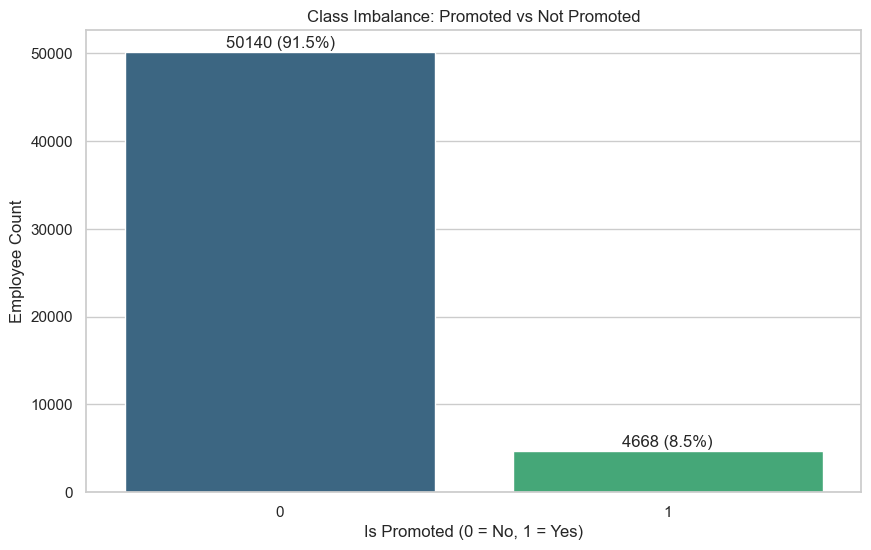

Overall promotion rate: 8.52%


In [143]:
promo_counts = df['is_promoted'].value_counts().sort_index()
promo_pct = df['is_promoted'].value_counts(normalize=True).sort_index() * 100

plt.figure()
sns.countplot(x='is_promoted', data=df, hue='is_promoted', palette='viridis', legend=False)
plt.title("Class Imbalance: Promoted vs Not Promoted")
plt.xlabel("Is Promoted (0 = No, 1 = Yes)")
plt.ylabel("Employee Count")
for i, v in enumerate(promo_counts):
    plt.text(i, v + 500, f"{v} ({promo_pct.iloc[i]:.1f}%)", ha='center')
plt.show()

print(f"Overall promotion rate: {df['is_promoted'].mean()*100:.2f}%")

**Comments on the Plot:**

Only 8.5% of employees were promoted, confirming this is a **severely imbalanced classification problem**.
This is the single most important finding for modeling stage - a model that simply predicts
"not promoted" for everyone would already be ~91% accurate while being completely useless, which is exactly
why `class_weight='balanced'` was flagged in the task allocation plan as the most important technical decision
in this project.


#### 3.2 Promotion Rate by Department

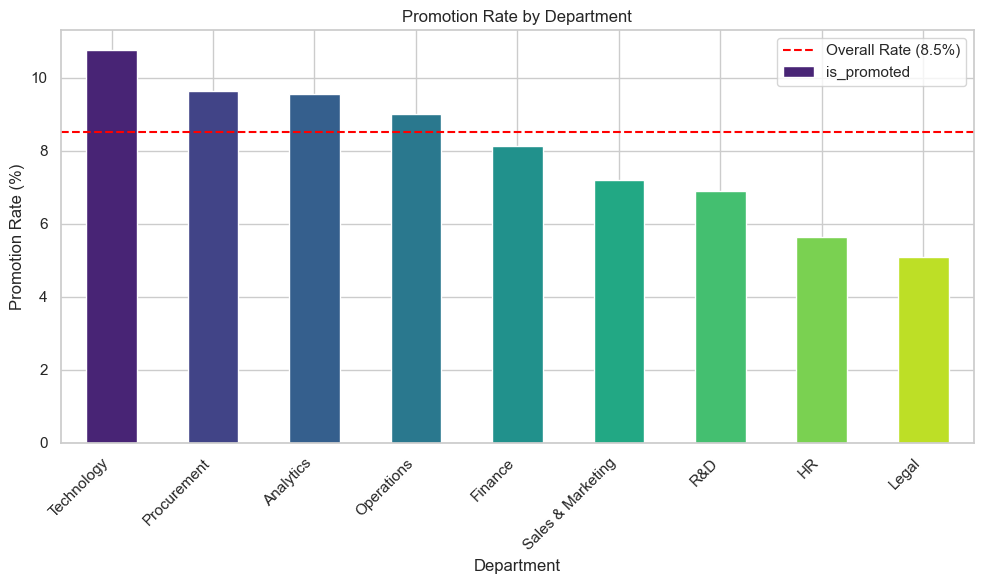

department
Technology           10.76
Procurement           9.64
Analytics             9.57
Operations            9.01
Finance               8.12
Sales & Marketing     7.20
R&D                   6.91
HR                    5.62
Legal                 5.10
Name: is_promoted, dtype: float64

In [144]:
overall_rate = df['is_promoted'].mean() * 100
dept_promo = df.groupby('department')['is_promoted'].mean().sort_values(ascending=False) * 100

plt.figure()
dept_promo.plot(kind='bar', color=sns.color_palette('viridis', len(dept_promo)))
plt.axhline(overall_rate, color='red', linestyle='--', label=f'Overall Rate ({overall_rate:.1f}%)')
plt.title("Promotion Rate by Department")
plt.ylabel("Promotion Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

dept_promo.round(2)

**Comments on the Plot:**

Promotion rates vary meaningfully by department - Technology and Procurement promote well above the company
average, while Legal and HR sit noticeably below it. This tells the modeling team that `department` carries
real predictive signal and should stay in the feature set, and it tells the dashboard that
department-level benchmarking will be a genuinely useful lens for HR, not just a cosmetic filter.


#### 3.3 Tenure Distribution: Promoted vs Non-Promoted

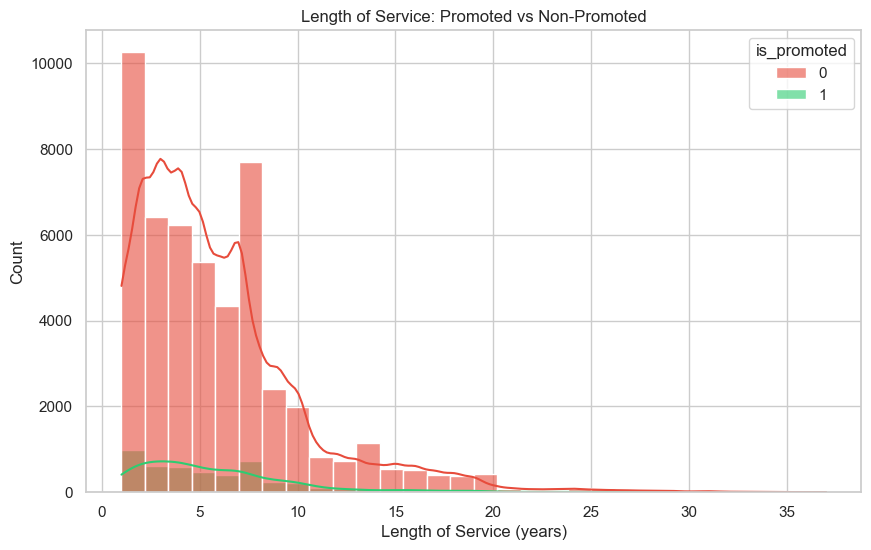

In [145]:
plt.figure()
sns.histplot(data=df, x='length_of_service', hue='is_promoted',
             kde=True, bins=30, palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title("Length of Service: Promoted vs Non-Promoted")
plt.xlabel("Length of Service (years)")
plt.ylabel("Count")
plt.show()

**Comments on the Plot:**

Both groups are concentrated in the early-tenure years, which makes sense given the company's overall  headcount skews junior - but the promoted group thins out less sharply at moderate tenure levels than the non-promoted group does. This is a mild signal rather than a dominant one, which matches what the correlation check below confirms.


#### 3.4 Correlation: Training Score, Awards, Rating vs Promotion

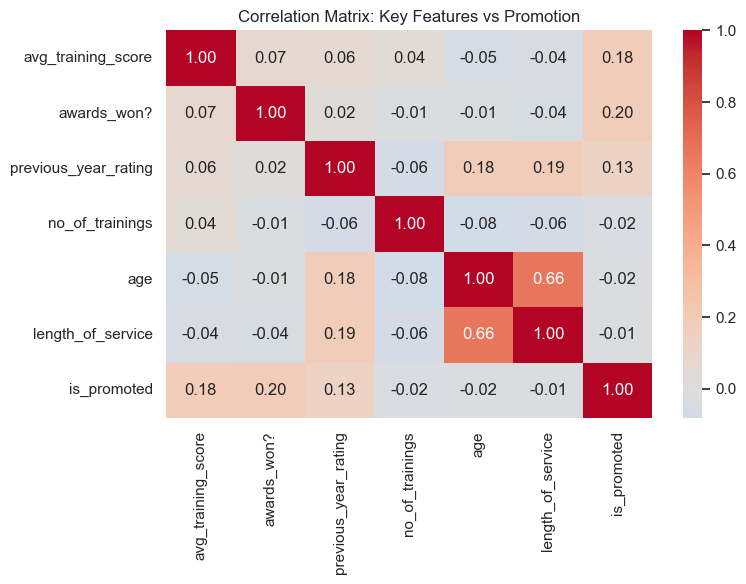

is_promoted             1.000000
awards_won?             0.195871
avg_training_score      0.181147
previous_year_rating    0.125991
length_of_service      -0.010670
age                    -0.017166
no_of_trainings        -0.024896
Name: is_promoted, dtype: float64

In [146]:
corr_cols = ['avg_training_score', 'awards_won?', 'previous_year_rating',
             'no_of_trainings', 'age', 'length_of_service', 'is_promoted']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Key Features vs Promotion")
plt.tight_layout()
plt.show()

corr_matrix['is_promoted'].sort_values(ascending=False)

**Comments on the Plot:**

`awards_won?` (0.20) and `avg_training_score` (0.18) are the two strongest predictors of promotion in this
dataset - meaningfully stronger than tenure, age, or number of trainings, which barely correlate at all.
This directly informs: these two fields deserve the most derived-feature
attention (e.g., training score buckets), while `age` and raw training count are unlikely to add much signal
on their own.


#### 3.5 Average Training Score by Promotion Status

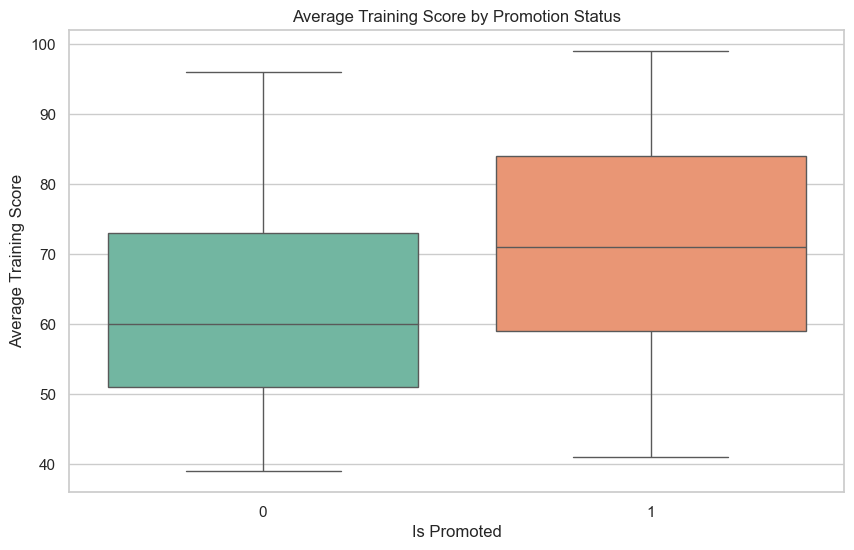

In [147]:
plt.figure()
sns.boxplot(x='is_promoted', y='avg_training_score', data=df, hue='is_promoted', palette='Set2', legend=False)
plt.title("Average Training Score by Promotion Status")
plt.xlabel("Is Promoted")
plt.ylabel("Average Training Score")
plt.show()

**Comments on the Plot:**

Promoted employees have a visibly higher median training score, with the whole distribution shifted upward
compared to non-promoted employees. This reinforces the correlation result above and makes training score a strong candidate for the "biggest gap" indicator planned for dashboard — a low training score relative to peers is an interpretable, actionable flag for HR.


#### 3.6 Awards Won vs Promotion Rate

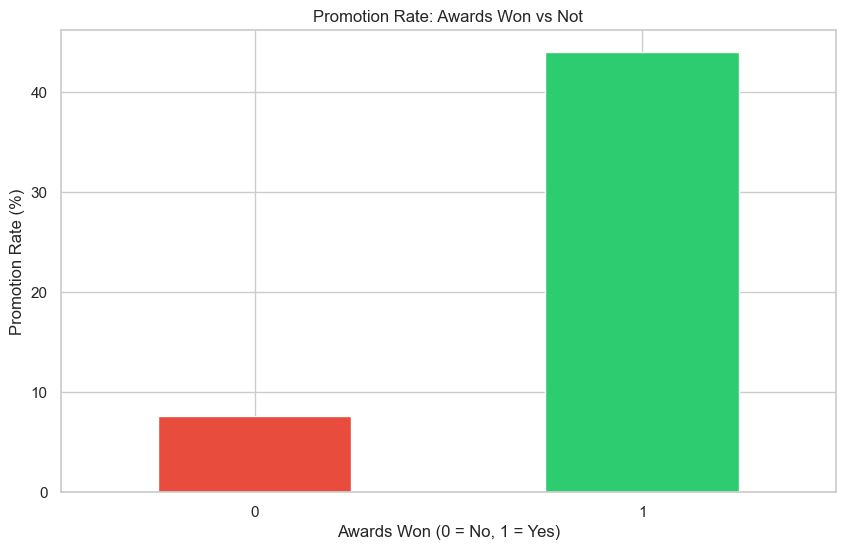

awards_won?
0     7.67
1    44.02
Name: is_promoted, dtype: float64

In [148]:
awards_promo = df.groupby('awards_won?')['is_promoted'].mean() * 100

plt.figure()
awards_promo.plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title("Promotion Rate: Awards Won vs Not")
plt.xlabel("Awards Won (0 = No, 1 = Yes)")
plt.ylabel("Promotion Rate (%)")
plt.xticks(rotation=0)
plt.show()

awards_promo.round(2)

**Comments on the Plot:**

The gap here is dramatic: employees who won an award get promoted **44% of the time**, versus roughly 8% for
those who didn't. This is by far the single strongest bivariate signal found in this EDA, and it's a good
candidate for the top "contributing factor" shown in the employee-lookup view of the dashboard, since it's
both highly predictive and easy for HR to explain.


# Feature Engineering & Baseline Model

**Employee Promotion Prediction Project**

This notebook covers:
- Loading and inspecting the cleaned dataset
- Engineering features: awards-won flag, training score buckets,
  education encoding, tenure ratio (KPI-met flag skipped — column
  not available in this dataset version, see note below)
- Preprocessing the data for modeling (encoding, scaling, train/test split)
- Training a baseline Logistic Regression model
- Evaluating the baseline with precision, recall, F1, ROC-AUC, and
  visualizations

Output: `preprocessed_promotion_data.csv`, used for the main
Random Forest model.

In [149]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score
)

In [150]:
df = pd.read_csv("cleaned_promotion_data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

Shape: (54808, 13)

Columns: ['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score', 'is_promoted']

First rows:
    employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other            

In [151]:
kpi_col = next((c for c in df.columns if "kpi" in c.lower()), None)

if kpi_col:
    print(f"Found KPI column: {kpi_col}")
    max_val = df[kpi_col].max()
    df["kpi_met_flag"] = (df[kpi_col] > (0.80 if max_val <= 1 else 80)).astype(int)
else:
    print("No KPI column in this dataset — kpi_met_flag skipped (documented in README).")

No KPI column in this dataset — kpi_met_flag skipped (documented in README).


In [152]:
awards_col = next((c for c in df.columns if "award" in c.lower()), None)
if awards_col:
    df["awards_won_flag"] = df[awards_col].astype(int)
    print(f"Created awards_won_flag from '{awards_col}'")

Created awards_won_flag from 'awards_won?'


In [153]:
score_col = next((c for c in df.columns if "training" in c.lower() and "score" in c.lower()), None)
if score_col:
    df["training_score_bucket"] = pd.cut(
        df[score_col],
        bins=[0, 40, 60, 80, 100],
        labels=["low", "medium", "high", "very_high"]
    )
    print(f"Created training_score_bucket from '{score_col}'")

Created training_score_bucket from 'avg_training_score'


In [154]:
edu_col = next((c for c in df.columns if "education" in c.lower()), None)
if edu_col:
    edu_map = {"Below Secondary": 0, "Bachelor's": 1, "Master's & above": 2}
    df["education_encoded"] = df[edu_col].map(edu_map)
    df["education_encoded"] = df["education_encoded"].fillna(df["education_encoded"].median())
    print(f"Created education_encoded from '{edu_col}'")

Created education_encoded from 'education'


In [155]:
tenure_col = next((c for c in df.columns if "length_of_service" in c.lower()), None)
if tenure_col:
    df["tenure_ratio"] = df[tenure_col] / df[tenure_col].max()
    print(f"Created tenure_ratio from '{tenure_col}'")

Created tenure_ratio from 'length_of_service'


In [156]:
df.to_csv("preprocessed_promotion_data.csv", index=False)
print("Saved preprocessed_promotion_data.csv")

Saved preprocessed_promotion_data.csv


In [157]:
target = "is_promoted"
raw_cols_to_drop = [c for c in [awards_col, edu_col, "training_score_bucket"] if c]

X = df.drop(columns=[target] + raw_cols_to_drop, errors="ignore")
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median(numeric_only=True))

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [158]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.77      0.86     10028
           1       0.21      0.65      0.32       934

    accuracy                           0.76     10962
   macro avg       0.58      0.71      0.59     10962
weighted avg       0.90      0.76      0.81     10962

=== Confusion Matrix ===
[[7751 2277]
 [ 329  605]]

ROC-AUC: 0.788
F1 Score: 0.3171


### What these numbers mean

Out of every 100 employees who were actually promoted, this baseline model
correctly flags about **65 of them** (recall = 0.65) — good, since missing
a promotion-ready employee is the costly mistake for HR.

However, when the model flags someone as "promotion-ready," it's only
right about **1 in 5 times** (precision = 0.21) — a lot of false alarms.

This trade-off is intentional: we used `class_weight='balanced'` so the
model doesn't just predict "not promoted" for everyone (which would give
a misleadingly high 91% accuracy while being useless). Overall accuracy
is 76%, and ROC-AUC is 0.79 — a solid, honest baseline for Member 3's
Random Forest model to try to beat.

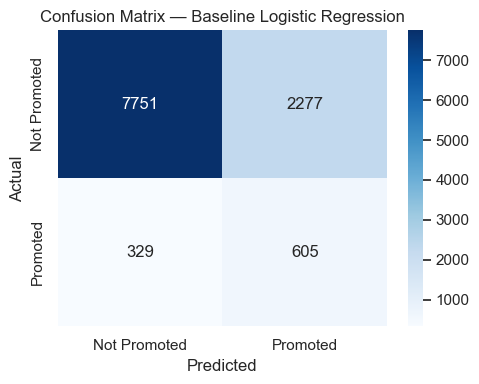

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Promoted", "Promoted"],
            yticklabels=["Not Promoted", "Promoted"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

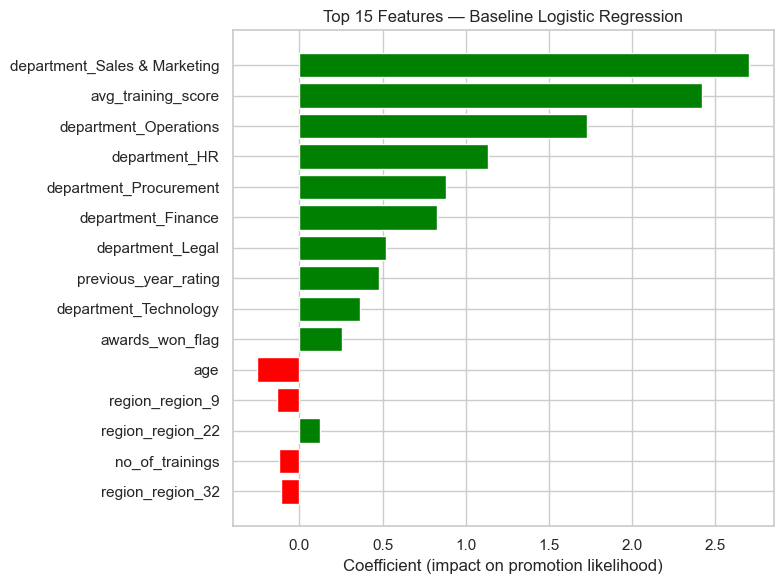

                         feature  coefficient
15  department_Sales & Marketing     2.703899
5             avg_training_score     2.417748
12         department_Operations     1.730417
10                 department_HR     1.132445
13        department_Procurement     0.881215
9             department_Finance     0.825636
11              department_Legal     0.522322
3           previous_year_rating     0.476799
16         department_Technology     0.361704
6                awards_won_flag     0.257916
2                            age    -0.252269
49               region_region_9    -0.136439
30              region_region_22     0.123497
1                no_of_trainings    -0.121090
41              region_region_32    -0.107735


In [160]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

top_features = coefficients.head(15)

plt.figure(figsize=(8, 6))
colors = ["green" if c > 0 else "red" for c in top_features["coefficient"]]
plt.barh(top_features["feature"], top_features["coefficient"], color=colors)
plt.xlabel("Coefficient (impact on promotion likelihood)")
plt.title("Top 15 Features — Baseline Logistic Regression")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print(top_features)

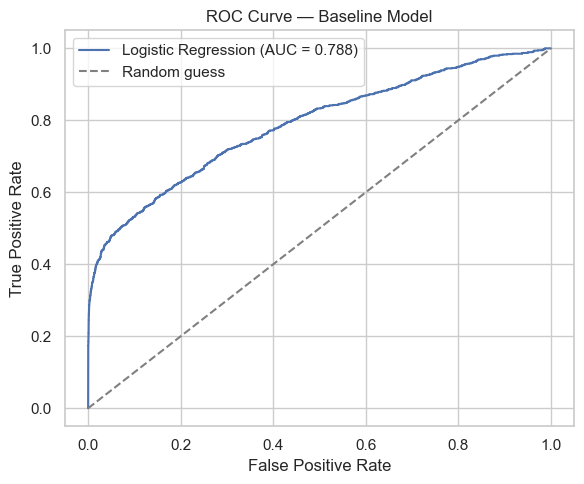

In [161]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Model")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

### Note on the missing KPI feature

The original Kaggle dataset includes a `KPIs_met >80%` column, but it is
**not present** in the version of `cleaned_promotion_data.csv` used for
this project. As a result, the planned `kpi_met_flag` feature could not
be engineered.

Since KPI achievement is typically a strong predictor of promotion in HR
data, its absence likely limits this baseline model's ceiling — this is
a known limitation to flag in the final report, not a bug in the code.

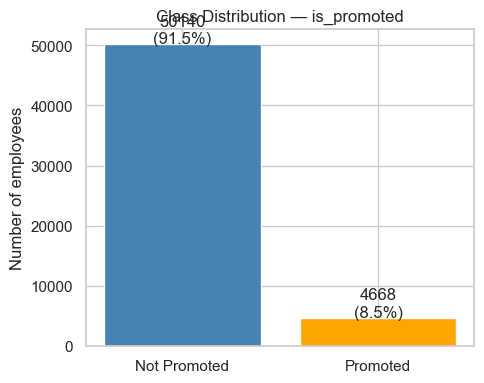

In [162]:
plt.figure(figsize=(5, 4))
counts = df["is_promoted"].value_counts()
bars = plt.bar(["Not Promoted", "Promoted"], counts.values, color=["steelblue", "orange"])

for bar, count in zip(bars, counts.values):
    pct = 100 * count / counts.sum()
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
              f"{count}\n({pct:.1f}%)", ha="center")

plt.ylabel("Number of employees")
plt.title("Class Distribution — is_promoted")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## 3. Advanced Modeling & Evaluation

This section trains the primary classifier — a Random Forest with `class_weight='balanced'` 
to handle the severe class imbalance in promotions — and evaluates it using precision, 
recall, F1-score, ROC-AUC, a confusion matrix, and feature importance.

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, 
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import joblib

In [164]:
df.dtypes[~df.dtypes.apply(lambda x: x.kind in 'iufb')]

department                 object
region                     object
education                  object
gender                     object
recruitment_channel        object
training_score_bucket    category
dtype: object

In [165]:
df_encoded = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns.tolist(), drop_first=True)

In [166]:
df_encoded['training_score_bucket'] = df_encoded['training_score_bucket'].astype(str)
df_encoded = pd.get_dummies(df_encoded, columns=['training_score_bucket'], drop_first=True)

In [167]:
df_encoded.dtypes[~df_encoded.dtypes.apply(lambda x: x.kind in 'iufb')]

Series([], dtype: object)

In [168]:
X = df_encoded.drop('is_promoted', axis=1)
y = df_encoded['is_promoted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(43846, 59) (10962, 59)


In [169]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [170]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [171]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.88      0.28      0.42       934

    accuracy                           0.94     10962
   macro avg       0.91      0.64      0.70     10962
weighted avg       0.93      0.94      0.92     10962



In [172]:
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.7862424184446292


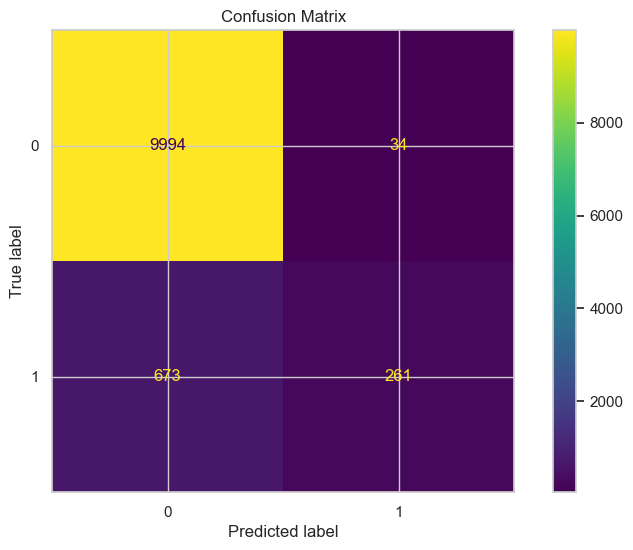

In [173]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.savefig('confusion_matrix.png')
plt.show()

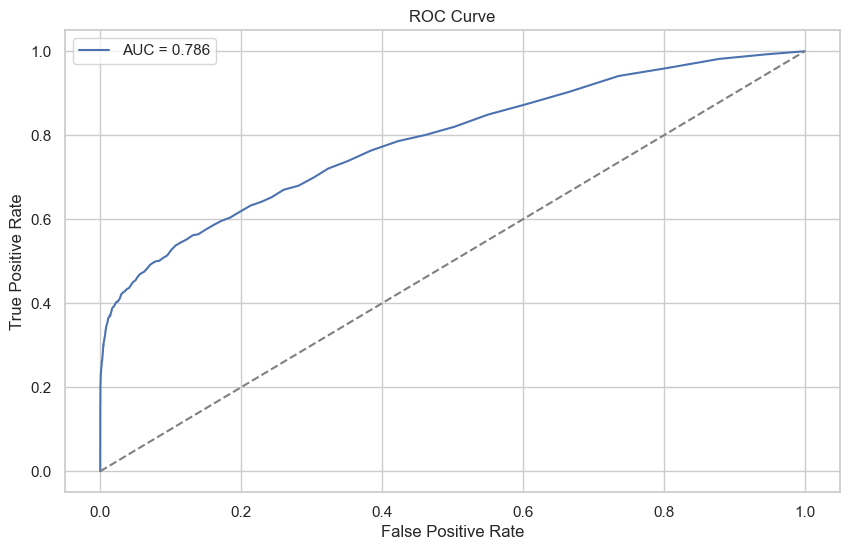

In [174]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig('roc_curve.png')
plt.show()

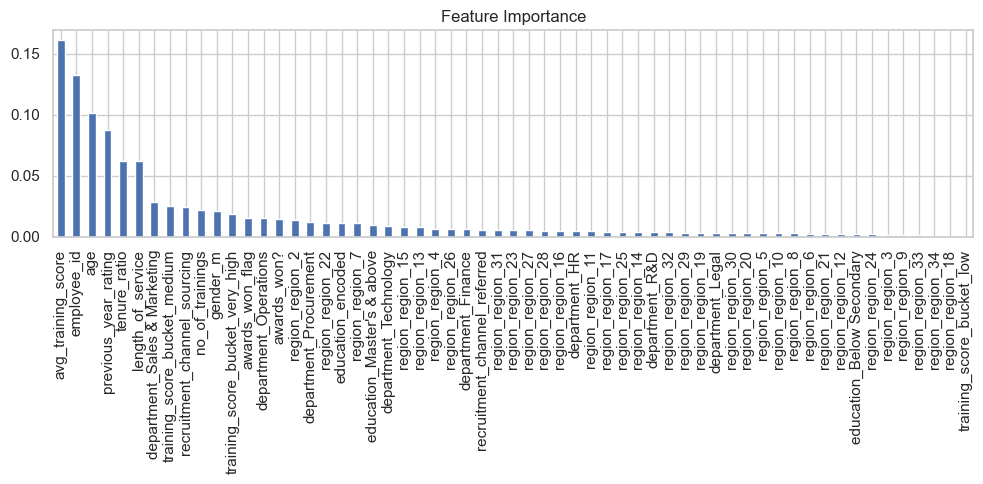

In [175]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [176]:
joblib.dump(rf, 'model.pkl')
print("Saved model.pkl")

Saved model.pkl


## 4. Dashboard Development

The trained model is deployed via a Streamlit web app (`app.py`) supporting employee 
lookup, department-level promotion rankings, and a "what-if" analysis. Streamlit apps run 
outside the notebook — this cell writes the app file to disk; run it with 
`streamlit run app.py` from a terminal.

In [177]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('model.pkl')
model_columns = joblib.load('model_columns.pkl')
df = pd.read_csv('cleaned_promotion_data.csv')  # match your actual raw filename

def prepare_input(raw_df):
    encoded = pd.get_dummies(raw_df, drop_first=True)
    encoded = encoded.reindex(columns=model_columns, fill_value=0)
    return encoded

st.title("Employee Promotion Predictor")

tab1, tab2, tab3 = st.tabs(["Employee Lookup", "Department Rankings", "What-If Analysis"])

with tab1:
    emp_id = st.selectbox("Select Employee ID", df['employee_id'].unique())
    emp_row = df[df['employee_id'] == emp_id].drop(columns=['is_promoted'], errors='ignore')
    X_input = prepare_input(emp_row)
    proba = model.predict_proba(X_input)[0][1]
    st.metric("Promotion Probability", f"{proba:.1%}")
    st.dataframe(emp_row)

with tab2:
    depts = df['department'].unique()
    dept_scores = {}
    for dept in depts:
        subset = df[df['department'] == dept].drop(columns=['is_promoted'], errors='ignore')
        X_dept = prepare_input(subset)
        dept_scores[dept] = model.predict_proba(X_dept)[:, 1].mean()
    scores_series = pd.Series(dept_scores).sort_values(ascending=False)
    st.bar_chart(scores_series)

with tab3:
    st.write("Adjust values to see how promotion probability changes")
    training_score = st.slider("Training Score", 0, 100, 60)
    sample = df.drop(columns=['is_promoted'], errors='ignore').iloc[[0]].copy()
    if 'avg_training_score' in sample.columns:
        sample['avg_training_score'] = training_score
    X_sample = prepare_input(sample)
    whatif_proba = model.predict_proba(X_sample)[0][1]
    st.metric("What-If Promotion Probability", f"{whatif_proba:.1%}")

Writing app.py


In [179]:
!dir app.py

 Volume in drive C has no label.
 Volume Serial Number is BAD3-8DA3

 Directory of c:\Users\Mr\Desktop\Employee-Promotion-Prediction-Engine\notebooks

09/02/2026  07:36 PM             1,799 app.py
               1 File(s)          1,799 bytes
               0 Dir(s)   3,112,210,432 bytes free
